**1.Import Libs and Dataset**

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
!pip install -q gdown
import gdown
!pip install -q segmentation_models_pytorch
import segmentation_models_pytorch as smp
import torch



In [ ]:
import kagglehub
thunderpede_panoramic_dental_dataset_path = kagglehub.dataset_download('thunderpede/panoramic-dental-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'panoramic-dental-dataset' dataset.
Data source import complete.


In [ ]:
# https://drive.google.com/drive/folders/1HpPNRxbuAJLJDMAzh4EntxHKw2VpmvHj?usp=sharing

file_id = '1ADJAJIjSJf5h-u_BR8mA5bWDMbipfDn4'
output  = 'UNetEfficientnetB0-best.pth'

gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ADJAJIjSJf5h-u_BR8mA5bWDMbipfDn4
From (redirected): https://drive.google.com/uc?id=1ADJAJIjSJf5h-u_BR8mA5bWDMbipfDn4&confirm=t&uuid=dc994338-2e89-468d-9d11-c8b0d7536979
To: /content/UNetEfficientnetB0-best.pth
100%|██████████| 26.7M/26.7M [00:00<00:00, 60.1MB/s]


'UNetEfficientnetB0-best.pth'

**1.Test on one sample**

✓ مدل لود شد
✓ mask ذخیره شد: /content/result_mask.png


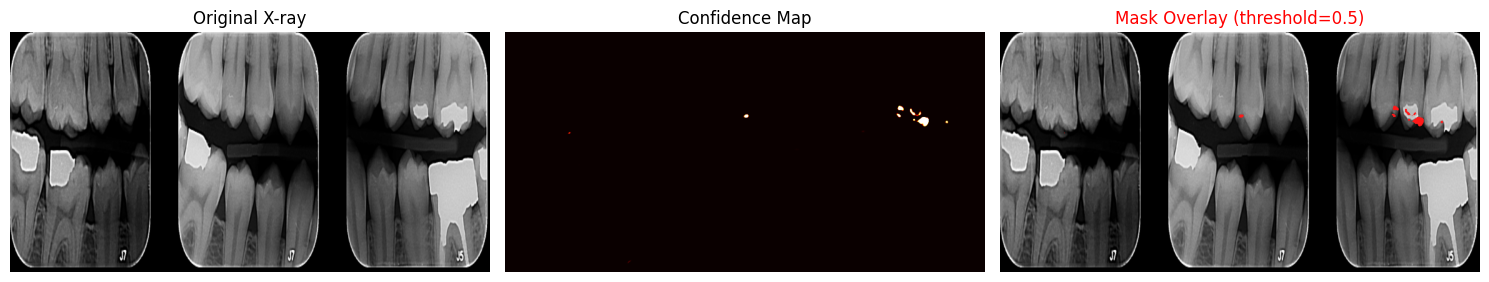

✓ overlay ذخیره شد: result_overlay.png


In [ ]:
MODEL_PATH  = '/content/UNetEfficientnetB0-best.pth'
IMAGE_PATH  = '/content/dataset/images/101_1.jpg'
OUTPUT_PATH = '/content/result_mask.png'
THRESHOLD   = 0.5
IMAGE_SIZE  = (384, 768)

device = 'cuda' if torch.cuda.is_available() else 'cpu'


model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.eval()
print("Model loaded!")

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.Grayscale(),
    transforms.ToTensor()
])

img = Image.open(IMAGE_PATH)
tensor = transform(img).unsqueeze(0).to(device)  # shape: (1, 1, 384, 768)

with torch.no_grad():
    logits = model(tensor)
    pred   = F.sigmoid(logits)

pred_np = pred.squeeze().cpu().numpy()
mask_binary = (pred_np >= THRESHOLD).astype(np.uint8) * 255

Image.fromarray(mask_binary).save(OUTPUT_PATH)
print(f"mask saved :  {OUTPUT_PATH}")

orig_resized = transform(img).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_resized, cmap='gray')
axes[0].set_title('Original X-ray', fontsize=12)
axes[0].axis('off')

axes[1].imshow(pred_np, cmap='hot')
axes[1].set_title('Confidence Map', fontsize=12)
axes[1].axis('off')

overlay = np.stack([orig_resized]*3, axis=-1)
overlay[mask_binary > 0] = [1.0, 0.1, 0.1]

axes[2].imshow(overlay)
axes[2].set_title(f'Mask Overlay (threshold={THRESHOLD})', fontsize=12, color='red')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('result_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print(" overlay  : result_overlay.png")

**2.Final results on 100 images**

In [ ]:
MODEL_PATH  = '/content/UNetEfficientnetB0-best.pth'
INPUT_DIR   = '/content/dataset/images'
OUTPUT_DIR  = '/content/masks_output'
THRESHOLD   = 0.5
IMAGE_SIZE  = (384, 768)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.eval()
print(f" Model loaded successfully on {device}")

# ── PREPROCESSING TRANSFORMS ─────────────
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.Grayscale(),
    transforms.ToTensor()
])

# ── INFERENCE FUNCTION ───────────────────
def process_single_image(image_path, output_path):

    try:
        img = Image.open(image_path)
        tensor = transform(img).unsqueeze(0).to(device)  # shape: (1, 1, 384, 768)

        # Inference
        with torch.no_grad():
            logits = model(tensor)
            pred   = F.sigmoid(logits)

        # Post-processing
        pred_np = pred.squeeze().cpu().numpy()
        mask_binary = (pred_np >= THRESHOLD).astype(np.uint8) * 255

        # Save binary mask
        Image.fromarray(mask_binary).save(output_path)
        return True
    except Exception as e:
        print(f"Error  {os.path.basename(image_path)}: {str(e)}")
        return False

os.makedirs(OUTPUT_DIR, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
all_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(image_extensions)]

print(f"Found {len(all_files)} images to process in '{INPUT_DIR}'\n")

success_count = 0
for file_name in all_files:
    full_input_path = os.path.join(INPUT_DIR, file_name)

    # Force output format to .png for masks as in your original script
    base_name = os.path.splitext(file_name)[0]
    full_output_path = os.path.join(OUTPUT_DIR, f"{base_name}_mask.png")

    # Run the function
    if process_single_image(full_input_path, full_output_path):
        success_count += 1
        print(f"Processed [{success_count}/{len(all_files)}]: {file_name} -> Saved mask")

print(f"\n Task completed! Successfully generated {success_count} masks in '{OUTPUT_DIR}'")

✓ Model loaded successfully on cpu
Found 110 images to process in '/content/dataset/images'

Processed [1/110]: 92_1.jpg -> Saved mask
Processed [2/110]: 34_1.jpg -> Saved mask
Processed [3/110]: 25_1.jpg -> Saved mask
Processed [4/110]: 94_1.jpg -> Saved mask
Processed [5/110]: 84_1.jpg -> Saved mask
Processed [6/110]: 88_1.jpg -> Saved mask
Processed [7/110]: 95_1.jpg -> Saved mask
Processed [8/110]: 49_1.jpg -> Saved mask
Processed [9/110]: 109_1.jpg -> Saved mask
Processed [10/110]: 70_1.jpg -> Saved mask
Processed [11/110]: 2_1.jpg -> Saved mask
Processed [12/110]: 39_1.jpg -> Saved mask
Processed [13/110]: 30_1.jpg -> Saved mask
Processed [14/110]: 74_1.jpg -> Saved mask
Processed [15/110]: 72_1.jpg -> Saved mask
Processed [16/110]: 32_1.jpg -> Saved mask
Processed [17/110]: 21_1.jpg -> Saved mask
Processed [18/110]: 105_1.jpg -> Saved mask
Processed [19/110]: 18_1.jpg -> Saved mask
Processed [20/110]: 104_1.jpg -> Saved mask
Processed [21/110]: 15_1.jpg -> Saved mask
Processed [